In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("bengaluru_house_prices.csv")
df.head(3)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00


In [7]:
df.shape

(13320, 9)

In [8]:
df.groupby("area_type")["area_type"].agg("count")

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [9]:
df.drop(["area_type","availability","society"],axis="columns",inplace=True)

In [10]:
df

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00
...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,0.0,231.00
13316,Richards Town,4 BHK,3600,5.0,NaN,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,1.0,488.00


In [11]:
df.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [12]:
df1=df.dropna()
df1.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [13]:
df1["size"].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',  '3 Bedroom',      '1 BHK',
       '1 RK',      '4 BHK',  '1 Bedroom',  '2 Bedroom',  '6 Bedroom',
  '8 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '11 Bedroom', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
 '10 Bedroom',     '13 BHK']
Length: 27, dtype: str

In [14]:
df1["bhk"]=df1["size"].apply(lambda x: int (x.split(' ')[0]))

In [15]:
df1[df1.bhk>20]

,location,size,total_sqft,bath,balcony,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,0.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,0.0,660.0,43


In [16]:
df1.total_sqft.unique()


<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '1310',        '1800',        '2785',        '1000',
 ...
        '1648',        '1379',        '3124',         '613',         '250',
        '2395',        '2758', '1133 - 1384',         '774',        '4689']
Length: 1976, dtype: str

In [17]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)
    except:
        return None


df2 = df1.copy()

# Make sure the column name is correct: total_sqft
df2["total_sqft"] = df2["total_sqft"].apply(convert_sqft_to_num)

df2.head()

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


In [18]:
df1.loc[30]

location        Yelahanka
size                4 BHK
total_sqft    2100 - 2850
bath                  4.0
balcony               0.0
price               186.0
bhk                     4
Name: 30, dtype: object

In [19]:
print(df1['total_sqft'].dtype)

str


In [20]:
df1['total_sqft'] = pd.to_numeric(df1['total_sqft'], errors='coerce')

In [21]:
df1.dtypes

location          str
size              str
total_sqft    float64
bath          float64
balcony       float64
price         float64
bhk             int64
dtype: object

In [22]:
df2 = df1.copy()
df2['price_per_sqft'] = (df2['price'] * 100000) / df2['total_sqft']
df2.head()

,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000


In [23]:
df2.location=df2.location.apply(lambda x: x.strip())

location_stats=df2.groupby("location")["location"].agg("count")
location_stats

location
1 Annasandrapalya                                  1
1 Giri Nagar                                       1
1 Ramamurthy Nagar                                 1
12th cross srinivas nagar banshankari 3rd stage    1
1A Block Koramangala                               1
                                                  ..
south                                              2
t.c palya                                          1
tc.palya                                           4
vinayakanagar                                      1
whitefiled                                         1
Name: location, Length: 1254, dtype: int64

In [24]:
len(location_stats[location_stats<=10])

1017

In [25]:
location_stats_10=location_stats[location_stats<=10]
location_stats_10

location
1 Annasandrapalya                                  1
1 Giri Nagar                                       1
1 Ramamurthy Nagar                                 1
12th cross srinivas nagar banshankari 3rd stage    1
1A Block Koramangala                               1
                                                  ..
south                                              2
t.c palya                                          1
tc.palya                                           4
vinayakanagar                                      1
whitefiled                                         1
Name: location, Length: 1017, dtype: int64

In [26]:
df2.location=df2.location.apply(lambda x: "other" if x in location_stats_10 else x)

In [27]:
len(df2.location.unique())

238

In [28]:
df2.head(10)

,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,1.0,38.00,2,3247.863248
8,Marathahalli,3 BHK,1310.0,3.0,1.0,63.25,3,4828.244275
10,Whitefield,3 BHK,1800.0,2.0,2.0,70.00,3,3888.888889
11,Whitefield,4 Bedroom,2785.0,5.0,3.0,295.00,4,10592.459605
12,7th Phase JP Nagar,2 BHK,1000.0,2.0,1.0,38.00,2,3800.000000


In [29]:
df2[df2.total_sqft/df2.bhk<300].head()

,location,size,total_sqft,bath,balcony,price,bhk,price_per_sqft
58,Murugeshpalya,6 Bedroom,1407.0,4.0,1.0,150.0,6,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350.0,7.0,0.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,2.0,100.0,3,20000.000000
78,Kaval Byrasandra,2 BHK,460.0,1.0,0.0,22.0,2,4782.608696
89,Rajaji Nagar,6 Bedroom,710.0,6.0,3.0,160.0,6,22535.211268


In [30]:
df2.shape

(12710, 8)

In [31]:
df3=df2[~(df2.total_sqft/df2.bhk<300)]
df3.shape

(12055, 8)

In [32]:
df3.price_per_sqft.describe()

count     11869.000000
mean       6220.296579
std        4004.343212
min         267.829813
25%        4198.473282
50%        5263.157895
75%        6844.741235
max      176470.588235
Name: price_per_sqft, dtype: float64

In [33]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby("location"):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out

df4 = remove_pps_outliers(df3)

print(df4.shape)

(9750, 8)


In [43]:
import matplotlib.pyplot as plt

def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]

    plt.figure(figsize=(15, 10))

    plt.scatter(
        bhk2.total_sqft,
        bhk2.price,
        color='blue',
        label='2 BHK',
        s=50
    )

    plt.scatter(
        bhk3.total_sqft,
        bhk3.price,
        marker='+',
        color='green',
        label='3 BHK',
        s=50
    )

    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()

    plt.show()

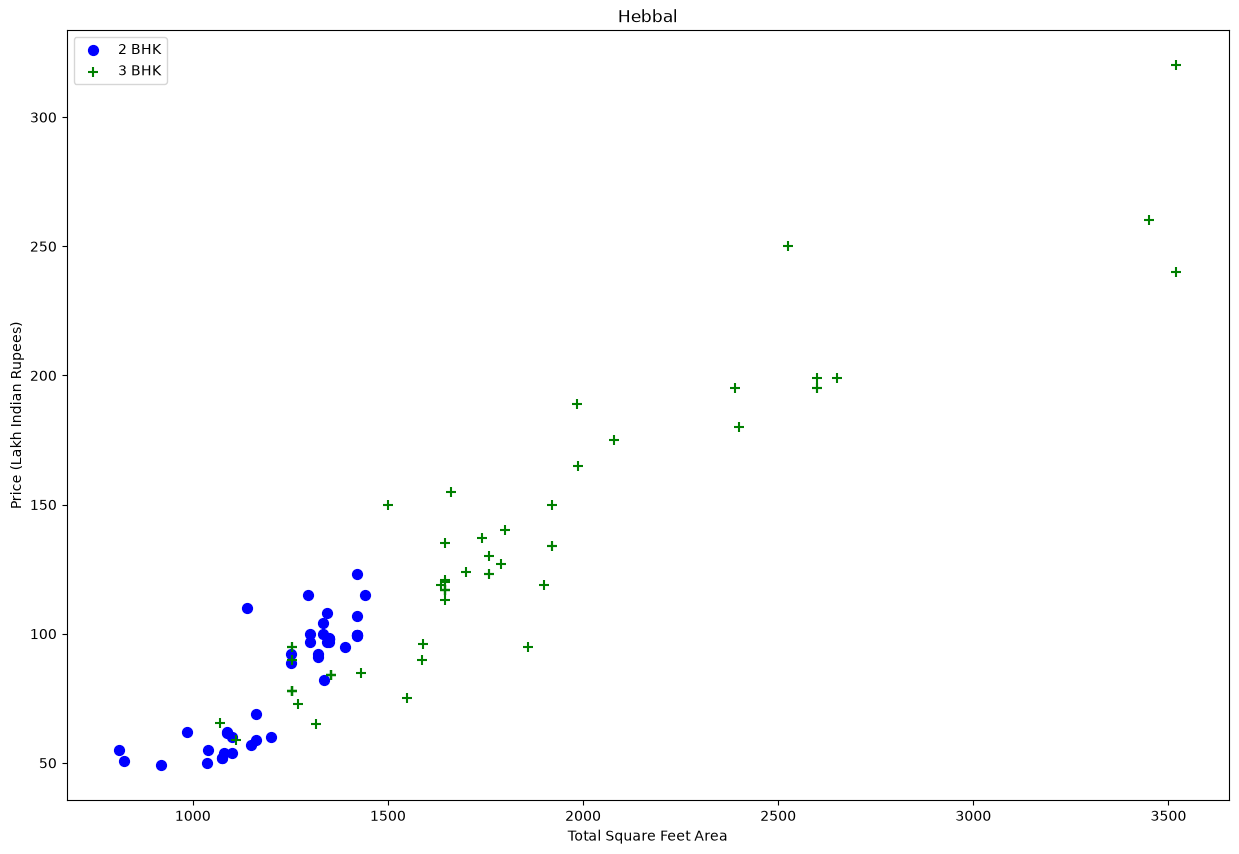

In [42]:
plot_scatter_chart(df4, "Hebbal")

In [38]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)

            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df.price_per_sqft < stats['mean']
                    ].index.values
                )

    return df.drop(exclude_indices, axis='index')
df5=remove_bhk_outliers(df4)
df5.shape

(6917, 8)

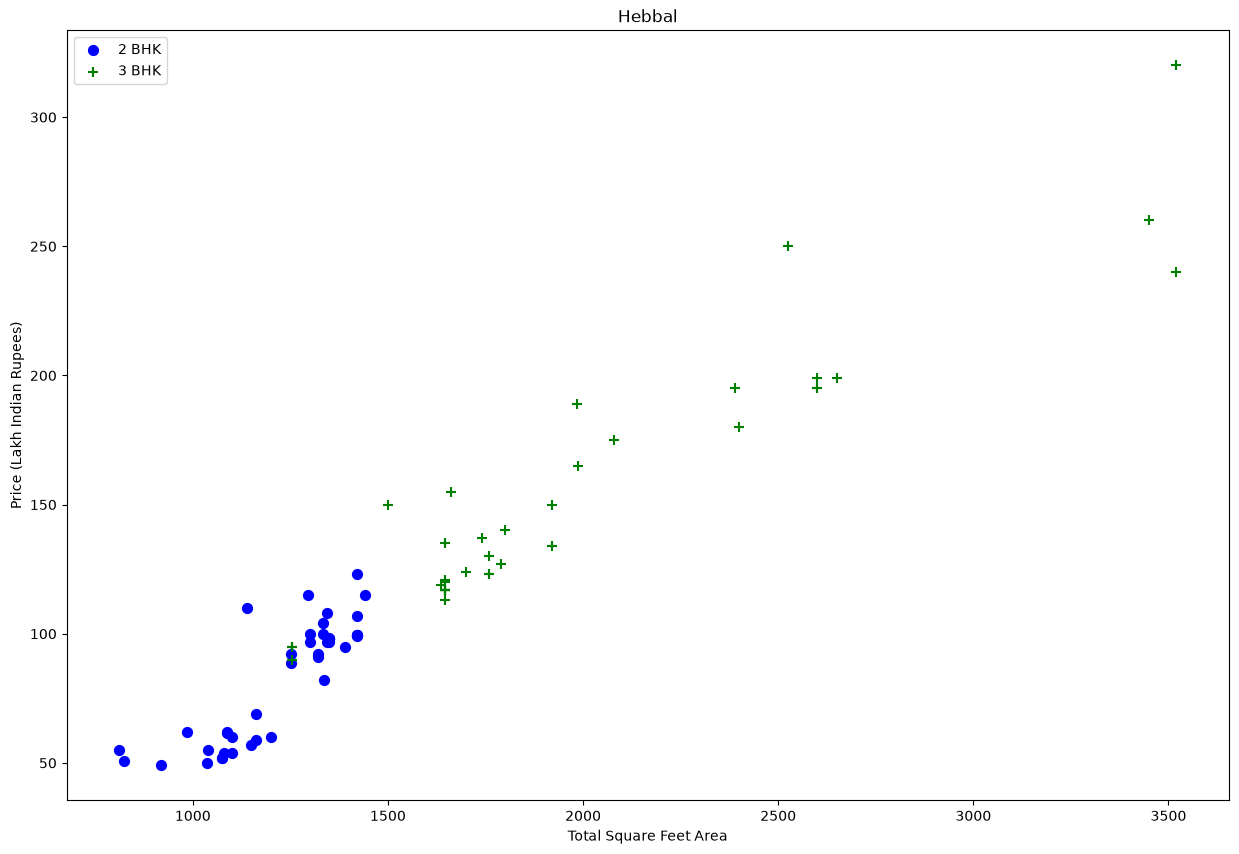

In [41]:
plot_scatter_chart(df5, "Hebbal")

In [44]:
df6=df5[df5.bath<df5.bhk+2]

In [45]:
df7=df6.drop(['size','price_per_sqft'],axis='columns')
df7.head

<bound method NDFrame.head of                  location  total_sqft  bath  balcony  price  bhk
0     1st Block Jayanagar      2850.0   4.0      1.0  428.0    4
1     1st Block Jayanagar      1630.0   3.0      2.0  194.0    3
2     1st Block Jayanagar      1875.0   2.0      3.0  235.0    3
3     1st Block Jayanagar      1200.0   2.0      0.0  130.0    3
4     1st Block Jayanagar      1235.0   2.0      2.0  148.0    2
...                   ...         ...   ...      ...    ...  ...
9740                other      1155.0   2.0      1.0   64.0    2
9742                other      1200.0   2.0      3.0   70.0    2
9743                other      1800.0   1.0      1.0  200.0    1
9746                other      1353.0   2.0      2.0  110.0    2
9747                other       812.0   1.0      0.0   26.0    1

[6855 rows x 6 columns]>

In [46]:
dummies=pd.get_dummies(df7.location)

In [47]:
df8=pd.concat([df7,dummies],axis='columns')

In [49]:
df8

,location,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9740,other,1155.0,2.0,1.0,64.0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9742,other,1200.0,2.0,3.0,70.0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9743,other,1800.0,1.0,1.0,200.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9746,other,1353.0,2.0,2.0,110.0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [64]:
df9=df8.drop("location",axis="columns")

In [65]:
X=df9.drop("price",axis="columns")
y=df9.price

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [67]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)

0.7842599354088388

In [63]:
print(X.columns)

Index(['location', 'total_sqft', 'bath', 'balcony', 'bhk',
       '1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Phase JP Nagar',
       ...
       'Vishveshwarya Layout', 'Vishwapriya Layout', 'Vittasandra',
       'Whitefield', 'Yelachenahalli', 'Yelahanka', 'Yelahanka New Town',
       'Yelenahalli', 'Yeshwanthpur', 'other'],
      dtype='str', length=243)


In [68]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.87846829, 0.7997512 , 0.76003073, 0.86730111, 0.84632774])

In [ ]:
def predict_price(location,sqft,bath,bhk):    
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1

    return lr_clf.predict([x])[0]

In [ ]:
predict_price('1st Phase JP Nagar',1000, 3, 2)

In [ ]:
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lr_clf,f)

In [ ]:
import json
columns = {
    'data_columns' : [col.lower() for col in X.columns]
}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))